# An LLM proposes, Jev decides: taxonomy induction on Amazon-C4

Jev is a decision model: it answers yes/no, choice and score questions fast and cheaply, but it cannot write. So the taxonomy is written by a cheap LLM and checked by Jev. `create_query_understanding` sees only the collection, never a query:

1. **Groups.** Cluster a 5,000-item sample into 80 groups (k-means on the stored embeddings).
2. **Names (LLM).** `qwen/qwen3.8-flash` reads 15 items of each group (10 diverse, 5 random) and writes a name, a definition and an exclusion.
3. **Checks (Jev).** A name stays if Jev places at least 40% of 15 random members under it and at most 15% of other groups' items. Groups the LLM named alike become one class.
4. **Parents (LLM).** The LLM groups the kept names into 10 to 20 parents.
5. **Coverage (Jev).** Parents are kept if they cover 0.5% to 40% of the sample; of two classes Jev accepts for mostly the same items, only the bigger one stays. Each child is scored only on its parent's items, as labeling will do; children of a rejected parent become top-level classes.

Then Jev labels all 20,000 items (a child only inside its parent) and reads each query once against every class; a child counts only when the query's parent scores at least 0.6, so queries and items agree. Search is hybrid (bge-small + BM25, RRF), and plain, boosted and filtered runs share one query path, so RRF ties break the same way in every arm.

**Evaluation.** The same protocol scores Amazon's own departments as a baseline. Every setting is picked on 300 dev queries (other Amazon-C4 queries whose targets are in the collection) and reported on 300 held-out test queries, with a paired bootstrap 95% CI.

A last section puts a Netflix-style router in front of Jev: a small classifier trained on Jev's item labels answers the queries it is sure about, so fewer queries wait for Jev.

**Cost**, about $3.50: naming and parents a few cents (LLM), Jev's name checks about $0.10, coverage about $0.40, labeling about $2.50 to $3, queries about $0.15. Labeling prices a small uncached pilot first and stops if the extrapolated cost exceeds `JEVQU_MAX_USD` (default $10).


In [1]:
import csv, dataclasses, json, os, random, re, sys, tempfile, time, urllib.request, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")        # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Payload indexes have no effect")  # in-memory Qdrant only

import matplotlib.pyplot as plt
import numpy as np
from fastembed import SparseTextEmbedding, TextEmbedding
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models

ROOT = Path.cwd() if (Path.cwd() / "jevqu").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.api import _sample, create_query_understanding, set_query_understanding, understand_query, upload_points
from jevqu.classify import classify_point
from jevqu.understand import understand
from jevqu.jev import Jev
from jevqu.llm import LLM
from jevqu.metrics import ndcg_at_k, paired_bootstrap, recall_at_k
from jevqu.qquery import build_filter, run
from jevqu.schema import ClassDef, Taxonomy, Thresholds, Understanding
from jevqu.text import state_from_payload

SEED = 0
N_QUERIES = 300           # evaluation queries: used only in step 3, never during induction
N_POINTS = 20_000         # the same collection as jevqu_c4_demo.ipynb
SAMPLE = 5_000            # items create_query_understanding looks at
K = 80                    # groups the LLM names
LLM_MODEL = "qwen/qwen3.8-flash"
N_DEV = 300               # dev queries for picking weights and thresholds
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "10"))
WORKERS = 8
DATA = ROOT / "data" / "c4"
COLLECTION = "c4-llm"
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "offline stand-in (no OPENROUTER_API_KEY)")

classifier: Jev (typesafe/jev-1.13) on OpenRouter


## 1. The collection

The same 300 queries and 20,000 items as the department demo: each query's target item plus a uniform sample of C4's 1M-item pool. Items carry only their text; Amazon's department is used only to describe the classes afterwards.

In [2]:
BASE = "https://huggingface.co/datasets/McAuley-Lab/Amazon-C4/resolve/main/"
DATA.mkdir(parents=True, exist_ok=True)
csv.field_size_limit(sys.maxsize)
for local, remote in [("test.csv", "test.csv"), ("items.jsonl", "sampled_item_metadata_1M.jsonl")]:
    if not (DATA / local).exists():
        urllib.request.urlretrieve(BASE + remote, DATA / local)

rng = random.Random(SEED)
with open(DATA / "test.csv", newline="") as f:
    c4_queries = list(csv.DictReader(f))
evalq = rng.sample(c4_queries, N_QUERIES)
targets = {q["item_id"] for q in evalq}
items, pool, seen = {}, [], 0
with open(DATA / "items.jsonl") as f:
    for line in f:
        d = json.loads(line)
        if d["item_id"] in targets:
            items[d["item_id"]] = d
            continue
        seen += 1
        if len(pool) < N_POINTS:
            pool.append(d)
        elif (j := rng.randrange(seen)) < N_POINTS:
            pool[j] = d
for d in pool[: N_POINTS - len(items)]:
    items[d["item_id"]] = d
catalog = list(items.values())
pid = {d["item_id"]: n for n, d in enumerate(catalog)}
qtexts = [q["query"] for q in evalq]
relevant = [{pid[q["item_id"]]} for q in evalq]
seen_q = {(q["query"], q["item_id"]) for q in evalq}
devq = random.Random(1).sample([q for q in c4_queries if q["item_id"] in pid and (q["query"], q["item_id"]) not in seen_q], N_DEV)
dev_texts = [q["query"] for q in devq]
dev_relevant = [{pid[q["item_id"]]} for q in devq]

def text(d):
    return d["metadata"][:600]

def title(d):
    return d["metadata"].split(". ")[0][:80]

def sparse_vec(s):
    return models.SparseVector(indices=s.indices.tolist(), values=s.values.tolist())

dense, bm25 = TextEmbedding("BAAI/bge-small-en-v1.5"), SparseTextEmbedding("Qdrant/bm25")
cache = DATA / f"dense_{SEED}_{N_QUERIES}_{N_POINTS}.npy"
if cache.exists():
    dvecs = np.load(cache)
else:
    dvecs = np.array(list(dense.embed([text(d) for d in catalog], batch_size=64)))
    np.save(cache, dvecs)
svecs = list(bm25.embed([text(d) for d in catalog]))

client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)
client.create_collection(COLLECTION,
    vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
    sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
points = [models.PointStruct(id=pid[d["item_id"]], vector={"dense": v.tolist(), "sparse": sparse_vec(s)},
                             payload={"item_id": d["item_id"], "text": text(d)})
          for d, v, s in zip(catalog, dvecs, svecs)]
client.upsert(COLLECTION, points)
print(f"{len(points):,} items indexed, {len(evalq)} test queries, {len(devq)} dev queries")

20,000 items indexed, 300 test queries, 300 dev queries


## 2. The classifier and the namer

With a key, Jev (`typesafe/jev-1.13`) through OpenRouter. Without one, a word-matching stand-in that only proves the notebook runs: its numbers mean nothing.
The namer is an LLM through OpenRouter; offline, a stand-in names each group by its most common word.


In [3]:
class OfflineStandIn:
    # Says yes when words of the class name appear in the text. Only for checking that the notebook runs.
    model = "offline"

    def ask(self, state, questions):
        blob = json.dumps(state).lower()
        out = {}
        for qid, q in questions.items():
            if q["type"] == "choice":  # class naming: take the encoder's top option
                out[qid] = {"type": "choice", "choice": next(iter(q["criteria"])), "confidence": 0.9}
                continue
            words = q["instructions"].split("`")[1].lower().split() if "`" in q["instructions"] else None
            hits = sum(w in blob for w in words) if words else 0
            p = 0.6 if words is None else 0.95 if hits >= 2 else 0.7 if hits == 1 else 0.05
            out[qid] = {"type": "noul", "noul": p}
        return out

class OfflineNamer:
    # Names a group by its most common longer word and puts all groups under one parent. Only for checking the notebook runs.
    usage = []

    def ask_json(self, system, user):
        lines = user.splitlines()[1:]
        if user.startswith("Example items"):
            w = Counter(x for l in lines for x in l.lower().split() if x.isalpha() and len(x) > 4).most_common(1)[0][0]
            return {"name": w, "definition": f"The item is a kind of {w}", "exclusions": "Other items", "coherent": True}
        return {"parents": [{"name": "products", "definition": "Any product", "exclusions": "Nothing", "children": list(range(len(lines)))}]}

jev = Jev(cache_dir=ROOT / ".jev_cache") if USE_JEV else OfflineStandIn()
llm = LLM(LLM_MODEL, cache_dir=ROOT / ".llm_cache") if USE_JEV else OfflineNamer()

def spent():
    return sum(getattr(jev, "usage", [])) + sum(getattr(llm, "usage", []))

def price_check(label, pilot_fn, n_pilot, n_total):
    # prices n_pilot fresh (uncached) requests and stops before a run above MAX_USD
    if not USE_JEV:
        return
    with tempfile.TemporaryDirectory() as d:
        fresh = Jev(cache_dir=d)
        pilot_fn(fresh)
    estimate = sum(fresh.usage) / n_pilot * n_total
    print(f"{label}: about ${estimate:.2f} for {n_total:,} requests (pilot of {n_pilot}, upper bound: cached answers are free)")
    assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD:.0f}"

## 3. Step 1: induce the taxonomy

`create_query_understanding` gets the collection, Jev and the namer, nothing else.


In [4]:
t0, s0 = time.time(), spent()
tax, report = create_query_understanding(client, COLLECTION, jev, sample=SAMPLE, llm=llm, k=K, workers=WORKERS)
level1, kids = tax.level1(), [c for c in tax.classes if c.parent]
print(f"{len(level1)} top-level classes ({sum(bool(r.get('promoted')) and r['kept'] for r in report)} of them promoted children) "
      f"and {len(kids)} children, in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f} (LLM ${sum(llm.usage):.4f})" if USE_JEV else ""))
assert spent() <= MAX_USD, f"step 1 spent more than JEVQU_MAX_USD=${MAX_USD:.0f}"


21 top-level classes (1 of them promoted children) and 49 children, in 2s, $0.0000 (LLM $0.0000)


In [5]:
name_of = {r["id"]: r["name"] for r in report}
rows = ["| class | level | parent | coverage of the sample | kept, or why not |", "|---|---|---|---|---|"]
for r in sorted(report, key=lambda r: (r.get("parent") is not None, name_of.get(r.get("parent"), ""), -r["coverage"])):
    level = "child" if r.get("parent") else "top (promoted)" if r.get("promoted") else "top"
    rows.append(f"| {r['name']} | {level} | {name_of.get(r.get('parent'), '')} | {r['coverage']:.1%} | "
                f"{'kept' if r['kept'] else r['rejected_by']} |")
display(Markdown("\n".join(rows)))


| class | level | parent | coverage of the sample | kept, or why not |
|---|---|---|---|---|
| Home Decor & Furnishings | top |  | 16.4% | kept |
| Electronics & Accessories | top |  | 13.3% | kept |
| Clothing & Apparel | top |  | 10.5% | kept |
| Tools & Hardware | top |  | 8.9% | kept |
| Books & Literature | top |  | 8.6% | kept |
| Cleaning & Organization | top |  | 8.4% | kept |
| Beauty & Personal Care | top |  | 8.3% | kept |
| Kitchen & Dining | top |  | 7.9% | kept |
| Toys, Games & Entertainment | top |  | 7.7% | kept |
| Crafts & Hobbies | top |  | 6.9% | kept |
| Health & Wellness | top |  | 6.6% | kept |
| Automotive & Vehicle Parts | top |  | 5.6% | kept |
| Food & Beverage | top |  | 5.2% | kept |
| Party & Seasonal Decor | top |  | 5.0% | kept |
| Pet Supplies | top |  | 4.6% | kept |
| Shoes & Footwear | top |  | 4.3% | kept |
| Bags & Luggage | top |  | 3.8% | kept |
| Garden & Outdoor | top |  | 3.8% | kept |
| Jewelry & Watches | top |  | 3.2% | kept |
| Furniture | top (promoted) |  | 2.5% | kept |
| Stickers & Decals | top |  | 1.3% | kept |
| Greeting Cards | top |  | 0.0% | fits few members |
| Desk Organizers | top |  | 0.0% | fits few members |
| Pet Supplies | top |  | 0.0% | fits few members |
| grooming brushes | top |  | 0.0% | fits few members |
| card supplies | top |  | 0.0% | fits few members |
| Party Favors | top |  | 0.0% | fits few members |
| adhesive supplies | top |  | 0.0% | fits few members |
| niche hobby gear | top |  | 0.0% | too broad |
| Tools and Accessories | top |  | 0.0% | too broad |
| fan apparel | top |  | 0.0% | fits few members |
| Vehicle Parts | child | Automotive & Vehicle Parts | 5.3% | same as parent |
| Car Parts | child | Automotive & Vehicle Parts | 4.0% | duplicates vehicle-parts |
| bags | child | Bags & Luggage | 2.7% | kept |
| Personal Care Products | child | Beauty & Personal Care | 6.8% | kept |
| Hair Care & Styling | child | Beauty & Personal Care | 2.6% | kept |
| makeup products | child | Beauty & Personal Care | 1.3% | kept |
| nail and lash supplies | child | Beauty & Personal Care | 0.9% | kept |
| protective eyewear | child | Beauty & Personal Care | 0.0% | size |
| Books | child | Books & Literature | 8.4% | same as parent |
| Romance Novels | child | Books & Literature | 1.7% | kept |
| cleaning supplies | child | Cleaning & Organization | 2.0% | kept |
| Storage Racks | child | Cleaning & Organization | 1.6% | kept |
| women's clothing | child | Clothing & Apparel | 5.4% | kept |
| men's clothing | child | Clothing & Apparel | 2.3% | kept |
| children's apparel | child | Clothing & Apparel | 1.2% | kept |
| Women's Dresses | child | Clothing & Apparel | 0.6% | kept |
| Craft Supplies | child | Crafts & Hobbies | 4.2% | kept |
| Musical Instruments | child | Crafts & Hobbies | 0.7% | kept |
| Electronic Accessories | child | Electronics & Accessories | 10.1% | kept |
| Electric Gadgets | child | Electronics & Accessories | 6.8% | kept |
| Computer Hardware | child | Electronics & Accessories | 3.3% | kept |
| device cases | child | Electronics & Accessories | 3.0% | kept |
| Audio Equipment | child | Electronics & Accessories | 1.9% | kept |
| batteries and chargers | child | Electronics & Accessories | 1.1% | kept |
| Mounting Hardware | child | Electronics & Accessories | 0.7% | kept |
| Power Cables | child | Electronics & Accessories | 0.6% | kept |
| food items | child | Food & Beverage | 4.1% | kept |
| Food and Drink | child | Food & Beverage | 3.6% | duplicates food-items |
| food and pet treats | child | Food & Beverage | 3.3% | duplicates food-items |
| Food Storage Containers | child | Food & Beverage | 0.9% | kept |
| Garden Decor | child | Garden & Outdoor | 1.3% | kept |
| Garden Plants | child | Garden & Outdoor | 0.4% | size |
| health supplements | child | Health & Wellness | 1.3% | kept |
| massage tools | child | Health & Wellness | 0.6% | kept |
| Home Decor | child | Home Decor & Furnishings | 13.4% | kept |
| home textiles | child | Home Decor & Furnishings | 5.3% | kept |
| bedding and furniture | child | Home Decor & Furnishings | 3.0% | kept |
| home hardware | child | Home Decor & Furnishings | 2.5% | kept |
| Wall Decor | child | Home Decor & Furnishings | 2.2% | kept |
| Lighting Fixtures | child | Home Decor & Furnishings | 2.0% | kept |
| outdoor decor | child | Home Decor & Furnishings | 1.8% | kept |
| bedding | child | Home Decor & Furnishings | 1.3% | kept |
| Home Fragrance | child | Home Decor & Furnishings | 0.4% | size |
| Japanese Home Goods | child | Home Decor & Furnishings | 0.1% | size |
| Jewelry | child | Jewelry & Watches | 2.2% | kept |
| Watches and Bands | child | Jewelry & Watches | 0.8% | kept |
| kitchen tools | child | Kitchen & Dining | 4.4% | kept |
| Drinkware | child | Kitchen & Dining | 1.4% | kept |
| Party Decorations | child | Party & Seasonal Decor | 4.1% | kept |
| Christmas Decorations | child | Party & Seasonal Decor | 1.5% | kept |
| Costume Accessories | child | Party & Seasonal Decor | 0.3% | size |
| dog accessories | child | Pet Supplies | 2.7% | kept |
| Footwear | child | Shoes & Footwear | 4.0% | same as parent |
| athletic footwear | child | Shoes & Footwear | 1.4% | kept |
| Decals and Stickers | child | Stickers & Decals | 1.2% | same as parent |
| Hardware and Tools | child | Tools & Hardware | 8.4% | same as parent |
| Replacement Parts | child | Tools & Hardware | 3.4% | kept |
| tools | child | Tools & Hardware | 2.7% | kept |
| Plumbing Parts | child | Tools & Hardware | 0.8% | kept |
| entertainment products | child | Toys, Games & Entertainment | 6.8% | kept |
| Toys and Games | child | Toys, Games & Entertainment | 4.7% | duplicates entertainment-products |
| Children's Toys | child | Toys, Games & Entertainment | 2.9% | kept |
| Media | child | Toys, Games & Entertainment | 1.5% | kept |

## 4. Step 2: label the collection

One request per item asks every top-level class; a second asks the children of the parents the item was placed in.


In [6]:
if not tax.classes:
    raise SystemExit("no classes kept: nothing to label or evaluate")
set_query_understanding(client, COLLECTION, tax)
price_check("step 2, labeling",
            lambda fresh: [classify_point(p.payload, tax, fresh) for p in points[:25]], 25, len(points))
t0, s0 = time.time(), spent()
failed = upload_points(client, COLLECTION, points, jev, workers=WORKERS)
print(f"labeled {len(points) - len(failed):,} items with {len(tax.classes)} classes in {time.time() - t0:.0f}s, "
      f"{len(failed)} failed" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))
stored = {pt.id: pt.payload for pt in client.scroll(COLLECTION, limit=len(points), with_payload=["classes"])[0]}
n_labels = Counter(len(stored[i].get("classes") or []) for i in stored)
print("labels per item:", dict(sorted(n_labels.items())),
      f"| items with any class: {np.mean([bool(stored[i].get('classes')) for i in stored]):.0%}")


step 2, labeling: about $2.15 for 20,000 requests (pilot of 25, upper bound: cached answers are free)


labeled 20,000 items with 70 classes in 6s, 0 failed, $0.0000
labels per item: {0: 593, 1: 3257, 2: 5975, 3: 4390, 4: 3146, 5: 1592, 6: 624, 7: 251, 8: 107, 9: 48, 10: 10, 11: 4, 12: 3} | items with any class: 97%


## 5. Step 3: score on held-out queries

Jev reads each query once, against every class. Strategies:

- **jevqu auto, defaults**: filter at P ≥ 0.9, boost at 0.6 to 0.9 with the library's default weight.
- **boost only**: no filters; every class at P ≥ 0.5 adds weight × P to the item's fused score. The weight is picked on the dev queries.
- **filter + boost**: hard filter above a threshold, boost below it; threshold and weight picked on the dev queries.
- **filter every guess** (P ≥ 0.5), for reference.


In [ ]:
t0, s0 = time.time(), spent()
with ThreadPoolExecutor(WORKERS) as ex:
    us = list(ex.map(lambda q: understand_query(client, COLLECTION, q, jev), qtexts))
    dev_us = list(ex.map(lambda q: understand_query(client, COLLECTION, q, jev), dev_texts))
emb = {"test": ([d.tolist() for d in dense.embed(qtexts)], [sparse_vec(s) for s in bm25.embed(qtexts)]),
       "dev": ([d.tolist() for d in dense.embed(dev_texts)], [sparse_vec(s) for s in bm25.embed(dev_texts)])}
split_of = {"test": (us, relevant), "dev": (dev_us, dev_relevant)}
print(f"understood {len(us) + len(dev_us)} queries in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))

def ranked(split, thresholds, mode="auto"):
    t = dataclasses.replace(tax, thresholds=thresholds)
    understood, _ = split_of[split]
    return [[h.id for h in run(client, COLLECTION, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(*emb[split], understood)]

def scores(split, r):
    rel = split_of[split][1]
    return ([ndcg_at_k(x, g, 10) for x, g in zip(r, rel)], [recall_at_k(x, g, 20) for x, g in zip(r, rel)])

base = {sp: scores(sp, ranked(sp, Thresholds(), "off")) for sp in split_of}
NEVER = 1.01  # a filter threshold no probability reaches
grid = {"boost only": [Thresholds(filter_above=NEVER, boost_above=0.5, boost_scale=w) for w in (0.03, 0.1, 0.3, 1.0)],
        "filter + boost": [Thresholds(filter_above=f, boost_above=0.5, boost_scale=w) for f in (0.9, 0.95) for w in (0.03, 0.1, 0.3, 1.0)]}
dev_rows, picked = ["| strategy | filter at | boost weight | dev change |", "|---|---|---|---|"], {}
for name, options in grid.items():
    best = None
    for th in options:
        d = 100 * (np.mean(scores("dev", ranked("dev", th))[0]) - np.mean(base["dev"][0]))
        dev_rows.append(f"| {name} | {'never' if th.filter_above > 1 else th.filter_above} | {th.boost_scale} | {d:+.2f} |")
        best = max(best or (d, th), (d, th), key=lambda x: x[0])
    picked[name] = best[1]
display(Markdown("**Dev sweep** (nDCG@10 change in points)\n\n" + "\n".join(dev_rows)))

results, rows = {}, ["| strategy | settings | nDCG@10 | change (95% CI) | recall@20 | queries changed |", "|---|---|---|---|---|---|",
                     f"| hybrid search | | {np.mean(base['test'][0]):.4f} | | {np.mean(base['test'][1]):.4f} | 0% |"]
base_run = ranked("test", Thresholds(), "off")
for name, th, mode in [("jevqu auto, defaults", Thresholds(), "auto"), ("boost only, picked on dev", picked["boost only"], "auto"),
                       ("filter + boost, picked on dev", picked["filter + boost"], "auto"),
                       ("filter every guess (P >= 0.5)", Thresholds(filter_above=0.5), "filter")]:
    r = ranked("test", th, mode)
    nd, rc = scores("test", r)
    d, lo, hi = paired_bootstrap(base["test"][0], nd)
    setting = f"filter {'never' if th.filter_above > 1 else th.filter_above}, boost {th.boost_scale}"
    results[name] = {"change": d, "ci": (lo, hi), "ndcg10": float(np.mean(nd)), "recall20": float(np.mean(rc)), "settings": setting}
    changed = np.mean([a != b for a, b in zip(r, base_run)])
    rows.append(f"| {name} | {setting} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} | {changed:.0%} |")
display(Markdown("**Test** (300 held-out queries)\n\n" + "\n".join(rows)))


understood 600 queries in 48s, $0.0000


**Dev sweep** (nDCG@10 change in points)

| strategy | filter at | boost weight | dev change |
|---|---|---|---|
| boost only | never | 0.03 | +1.26 |
| boost only | never | 0.1 | +2.88 |
| boost only | never | 0.3 | +2.86 |
| boost only | never | 1.0 | +0.75 |
| filter + boost | 0.9 | 0.03 | +1.87 |
| filter + boost | 0.9 | 0.1 | +2.65 |
| filter + boost | 0.9 | 0.3 | +2.05 |
| filter + boost | 0.9 | 1.0 | -0.28 |
| filter + boost | 0.95 | 0.03 | +1.51 |
| filter + boost | 0.95 | 0.1 | +2.61 |
| filter + boost | 0.95 | 0.3 | +2.11 |
| filter + boost | 0.95 | 1.0 | +0.13 |

**Test** (300 held-out queries)

| strategy | settings | nDCG@10 | change (95% CI) | recall@20 | queries changed |
|---|---|---|---|---|---|
| hybrid search | | 0.2932 | | 0.5300 | 0% |
| jevqu auto, defaults | filter 0.9, boost 0.1 | 0.3277 | +0.0345 (+0.0160 to +0.0540) | 0.5767 | 88% |
| boost only, picked on dev | filter never, boost 0.1 | 0.3246 | +0.0314 (+0.0206 to +0.0439) | 0.5767 | 91% |
| filter + boost, picked on dev | filter 0.9, boost 0.1 | 0.3314 | +0.0382 (+0.0191 to +0.0572) | 0.5733 | 92% |
| filter every guess (P >= 0.5) | filter 0.5, boost 0.1 | 0.3012 | +0.0080 (-0.0182 to +0.0360) | 0.5100 | 88% |

### How the hard filters behaved (filter + boost, as picked on dev)

A wrong filter removes the target item; a right one moves it up. What matters is how often a filter fires and how often it is right.


In [8]:
th = picked["filter + boost"]
auto_ndcg, _ = scores("test", ranked("test", th))
delta = 100 * (np.array(auto_ndcg) - np.array(base["test"][0]))
tgt = [next(iter(rel)) for rel in relevant]
fired = [[c for c, p in u.classes if p >= th.filter_above] for u in us]
right = np.array([bool(f) and all(c in (stored[t].get("classes") or []) for c in f) for f, t in zip(fired, tgt)])
wrong = np.array([bool(f) for f in fired]) & ~right
labeled = np.array([bool(stored[t].get("classes")) for t in tgt])
mean = lambda m: f"{delta[m].mean():+.2f}" if m.any() else "n/a"
n_f = int(right.sum() + wrong.sum())
print(f"filters fired on {n_f} of {len(us)} queries ({n_f / len(us):.0%}), kept the target on {right.sum()} "
      f"({right.sum() / max(1, n_f):.0%}; break-even about 85%)")
print(f"change per right filter {mean(right)} pts, per wrong filter {mean(wrong)} pts")
print(f"target items with any class: {labeled.mean():.0%}; change on those queries {mean(labeled)}, on the rest {mean(~labeled)} pts")


filters fired on 214 of 300 queries (71%), kept the target on 197 (92%; break-even about 85%)
change per right filter +6.05 pts, per wrong filter -14.71 pts
target items with any class: 97%; change on those queries +3.97, on the rest -1.77 pts


### Baseline: Amazon's own departments, same protocol

The catalog's 31 departments with hand-expanded names and three example titles each (as in `jevqu_c4_demo.ipynb`), labeled by Jev and scored exactly like the induced taxonomy: same collection, same search path, settings picked on the same dev queries.


In [9]:
DEPARTMENTS = {
    "Appliances": "Appliances", "Arts": "Arts, Crafts and Sewing", "Automotive": "Automotive",
    "Baby": "Baby Products", "Beauty": "All Beauty", "Books": "Books", "CDs": "CDs and Vinyl",
    "Care": "Beauty and Personal Care", "Cell": "Cell Phones and Accessories",
    "Clothing": "Clothing, Shoes and Jewelry", "Electronics": "Electronics", "Fashion": "Amazon Fashion",
    "Food": "Grocery and Gourmet Food", "Games": "Video Games", "Garden": "Patio, Lawn and Garden",
    "Gift": "Gift Cards", "Handmade": "Handmade Products", "Health": "Health and Personal Care",
    "Home": "Home and Kitchen", "Household": "Health and Household", "Instruments": "Musical Instruments",
    "Kindle": "Kindle Store", "Magazine": "Magazine Subscriptions", "Movies": "Movies and TV",
    "Office": "Office Products", "Pet": "Pet Supplies", "Scientific": "Industrial and Scientific",
    "Software": "Software", "Sports": "Sports and Outdoors", "Toys": "Toys and Games",
    "Tools": "Tools and Home Improvement"}
dept_slug = lambda s: re.sub(r"[^a-z0-9]+", "-", s.lower()).strip("-")
dept_examples = defaultdict(list)
for d in catalog:
    dept_examples[d["category"]].append(title(d))
dept_tax = Taxonomy("c4-departments-v1", jev.model, [
    ClassDef(dept_slug(c), DEPARTMENTS.get(c, c), f"The product belongs in Amazon's '{DEPARTMENTS.get(c, c)}' department, "
             "for example: " + "; ".join(dept_examples[c][:3]), "Products from any other department") for c in sorted(dept_examples)],
    facets=[], thresholds=Thresholds())
t0, s0 = time.time(), spent()
with ThreadPoolExecutor(WORKERS) as ex:
    dept_labels = list(ex.map(lambda p: classify_point(p.payload, dept_tax, jev), points))
    dept_us = {sp: list(ex.map(lambda q: understand(q, dept_tax, jev), qt)) for sp, qt in (("test", qtexts), ("dev", dev_texts))}
DEPT = "c4-departments"
if client.collection_exists(DEPT):
    client.delete_collection(DEPT)
client.create_collection(DEPT, vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
                         sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
client.upsert(DEPT, [models.PointStruct(id=p.id, vector=p.vector, payload={"classes": l["classes"]}) for p, l in zip(points, dept_labels)])
print(f"departments: {np.mean([bool(l['classes']) for l in dept_labels]):.0%} of items labeled, in {time.time() - t0:.0f}s"
      + (f", ${spent() - s0:.4f}" if USE_JEV else ""))

def dept_ranked(split, thresholds, mode="auto"):
    t = dataclasses.replace(dept_tax, thresholds=thresholds)
    return [[h.id for h in run(client, DEPT, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(*emb[split], dept_us[split])]

dept_picked = {}
for name, options in grid.items():
    dept_picked[name] = max(options, key=lambda th: np.mean(scores("dev", dept_ranked("dev", th))[0]))
dept_results, rows = {}, ["| Amazon departments | settings | nDCG@10 | change (95% CI) | recall@20 |", "|---|---|---|---|---|"]
for name, th, mode in [("jevqu auto, defaults", Thresholds(), "auto"), ("boost only, picked on dev", dept_picked["boost only"], "auto"),
                       ("filter + boost, picked on dev", dept_picked["filter + boost"], "auto"),
                       ("filter every guess (P >= 0.5)", Thresholds(filter_above=0.5), "filter")]:
    nd, rc = scores("test", dept_ranked("test", th, mode))
    d, lo, hi = paired_bootstrap(base["test"][0], nd)
    setting = f"filter {'never' if th.filter_above > 1 else th.filter_above}, boost {th.boost_scale}"
    dept_results[name] = {"change": d, "ci": (lo, hi), "ndcg10": float(np.mean(nd)), "recall20": float(np.mean(rc)), "settings": setting}
    rows.append(f"| {name} | {setting} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} |")
display(Markdown("**Test** (same 300 held-out queries)\n\n" + "\n".join(rows)))


departments: 95% of items labeled, in 5s, $0.0000


**Test** (same 300 held-out queries)

| Amazon departments | settings | nDCG@10 | change (95% CI) | recall@20 |
|---|---|---|---|---|
| jevqu auto, defaults | filter 0.9, boost 0.1 | 0.3135 | +0.0203 (+0.0106 to +0.0303) | 0.5767 |
| boost only, picked on dev | filter never, boost 0.3 | 0.3226 | +0.0294 (+0.0190 to +0.0410) | 0.5767 |
| filter + boost, picked on dev | filter 0.9, boost 0.3 | 0.3239 | +0.0307 (+0.0176 to +0.0443) | 0.5867 |
| filter every guess (P >= 0.5) | filter 0.5, boost 0.1 | 0.3300 | +0.0368 (+0.0209 to +0.0529) | 0.5667 |

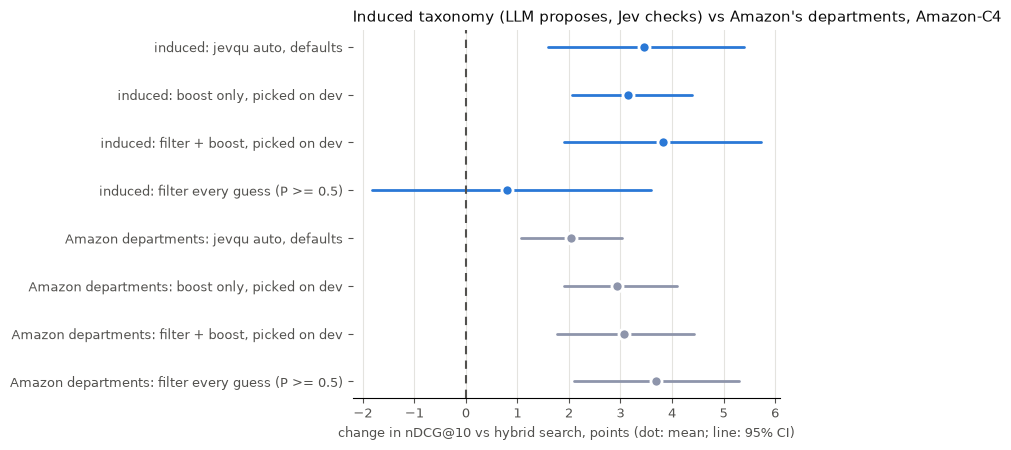

In [10]:
BLUE, INK, MUTED, GRID, GREY = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df", "#8e95ab"
names = [f"induced: {k}" for k in results] + [f"Amazon departments: {k}" for k in dept_results]
vals = [(v["change"], *v["ci"]) for v in results.values()] + [(v["change"], *v["ci"]) for v in dept_results.values()]
fig, ax = plt.subplots(figsize=(8, 4.6))
ys = list(range(len(names)))[::-1]
for y, name, (d, lo, hi) in zip(ys, names, vals):
    color = GREY if name.startswith("Amazon") else BLUE
    ax.plot([100 * lo, 100 * hi], [y, y], color=color, lw=2, solid_capstyle="round")
    ax.plot(100 * d, y, "o", color=color, ms=8, markeredgecolor="white", markeredgewidth=2)
ax.axvline(0, color=MUTED, lw=1.5, ls=(0, (4, 3)))
ax.set_yticks(ys, names)
ax.set_xlabel("change in nDCG@10 vs hybrid search, points (dot: mean; line: 95% CI)", color=MUTED, fontsize=9)
ax.set_title("Induced taxonomy (LLM proposes, Jev checks) vs Amazon's departments, Amazon-C4", loc="left", color=INK, fontsize=11)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## 6. Routing like Netflix: a cheap model in front of Jev

Every query waits for one Jev request, about 1.9 s with 70 classes in our run. Netflix keeps its slow model off the hot path by routing: a cheap model answers the queries it is sure about, and only the rest go to the slow one.

Here the cheap model is free to build. Jev has already labeled every item, so one small classifier per class, trained on those labels with the item vectors, can read the query's dense vector (computed for search anyway) in about a millisecond. When its top class reaches a threshold, its answer is used, as a boost only; otherwise the query goes to Jev. The threshold is picked on the dev queries.


In [11]:
from sklearn.linear_model import LogisticRegression

JEV_SECONDS = 1.9  # one 70-class query request in the paid run: 600 queries in 141 s, 8 at a time
ids = [c.id for c in tax.classes]
X = dvecs / np.linalg.norm(dvecs, axis=1, keepdims=True)
Y = np.array([[c in set(stored[i].get("classes") or []) for c in ids] for i in range(len(points))])
t0 = time.time()
heads = [LogisticRegression(C=4.0, max_iter=300).fit(X, Y[:, j]) if 0 < Y[:, j].sum() < len(Y) else None
         for j in range(len(ids))]
print(f"trained {sum(h is not None for h in heads)} classifiers on Jev's item labels in {time.time() - t0:.1f}s")

def small_model(split):
    q = np.array(emb[split][0])
    q /= np.linalg.norm(q, axis=1, keepdims=True)
    P = np.column_stack([h.predict_proba(q)[:, 1] if h is not None else np.zeros(len(q)) for h in heads])
    return [Understanding([(c.id, p[c.id]) for c in tax.classes
                           if c.parent is None or p[c.parent] >= tax.thresholds.boost_above], {}, "small")
            for p in (dict(zip(ids, row.tolist())) for row in P)]  # the same parent rule as Jev
small_us = {sp: small_model(sp) for sp in split_of}

fb = picked["filter + boost"]
boost_only = dataclasses.replace(fb, filter_above=NEVER)
def routed(split, tau):
    sure = [max((p for _, p in u.classes), default=0.0) >= tau for u in small_us[split]]
    mixed = [s if ok else j for s, j, ok in zip(small_us[split], split_of[split][0], sure)]
    r = [[h.id for h in run(client, COLLECTION, d, s, u, dataclasses.replace(tax, thresholds=boost_only if ok else fb),
                            limit=20, mode="auto")] for d, s, u, ok in zip(*emb[split], mixed, sure)]
    return scores(split, r)[0], float(np.mean(sure))

dev_sweep = {tau: routed("dev", tau) for tau in (0.8, 0.9, 0.95)}
gain = lambda nd, sp: 100 * (np.mean(nd) - np.mean(base[sp][0]))
tau = max(dev_sweep, key=lambda t: (round(gain(dev_sweep[t][0], "dev"), 1), dev_sweep[t][1]))
print("dev: " + " | ".join(f"tau {t}: {gain(nd, 'dev'):+.2f} with {s:.0%} answered by the small model" for t, (nd, s) in dev_sweep.items()))

router_results, rows = {}, ["| strategy | answered without Jev | Jev requests | average Jev wait | nDCG@10 change (95% CI) |",
                            "|---|---|---|---|---|"]
small_only = [[h.id for h in run(client, COLLECTION, d, s, u, dataclasses.replace(tax, thresholds=boost_only), limit=20, mode="auto")]
              for d, s, u in zip(*emb["test"], small_us["test"])]
for name, nd, share in [("Jev on every query (filter + boost)", scores("test", ranked("test", fb))[0], 0.0),
                        ("small model only (boost)", scores("test", small_only)[0], 1.0),
                        (f"router: small model when P >= {tau}, else Jev", *routed("test", tau))]:
    d, lo, hi = paired_bootstrap(base["test"][0], nd)
    router_results[name] = {"change": d, "ci": (lo, hi), "answered_without_jev": share, "jev_wait_s": (1 - share) * JEV_SECONDS}
    rows.append(f"| {name} | {share:.0%} | {1 - share:.0%} | {(1 - share) * JEV_SECONDS:.2f} s | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) |")
display(Markdown("**Test** (300 held-out queries)\n\n" + "\n".join(rows)))


trained 70 classifiers on Jev's item labels in 1.2s


dev: tau 0.8: +2.56 with 64% answered by the small model | tau 0.9: +2.49 with 54% answered by the small model | tau 0.95: +2.70 with 40% answered by the small model


**Test** (300 held-out queries)

| strategy | answered without Jev | Jev requests | average Jev wait | nDCG@10 change (95% CI) |
|---|---|---|---|---|
| Jev on every query (filter + boost) | 0% | 100% | 1.90 s | +0.0382 (+0.0191 to +0.0572) |
| small model only (boost) | 100% | 0% | 0.00 s | +0.0128 (+0.0048 to +0.0221) |
| router: small model when P >= 0.95, else Jev | 37% | 63% | 1.20 s | +0.0398 (+0.0228 to +0.0574) |

## 7. What the induced classes look like

For each kept class (children under their parent): how many items Jev labeled with it, which Amazon departments those items come from, and three example items. Then how the queries used them.

In [12]:
members = defaultdict(list)
for d in catalog:
    for c in stored[pid[d["item_id"]]].get("classes") or []:
        members[c].append(d)
name_of = {c.id: c.name for c in tax.classes}
order = [c for p in sorted(level1, key=lambda c: -len(members[c.id])) for c in [p] + tax.children(p.id)]
rows = ["| class | parent | items | top Amazon departments | examples |", "|---|---|---|---|---|"]
for c in order:
    ds = members[c.id]
    top = ", ".join(f"{k} {n / max(1, len(ds)):.0%}" for k, n in Counter(d["category"] for d in ds).most_common(2))
    ex = "; ".join(title(d)[:45] for d in ds[:3])
    rows.append(f"| {'&nbsp;&nbsp;' if c.parent else ''}{c.name} | {name_of.get(c.parent, '')} | {len(ds):,} | {top} | {ex} |")
display(Markdown("\n".join(rows)))

top_q = [max(u.classes, key=lambda kv: kv[1]) if u.classes else (None, 0.0) for u in us]
hit = [p >= 0.6 for _, p in top_q]
print(f"queries with a class at P >= 0.6: {np.mean(hit):.0%}; at P >= 0.9: {np.mean([p >= 0.9 for _, p in top_q]):.0%}")
for i in [i for i, h in enumerate(hit) if h][:4]:
    cid, p = top_q[i]
    f = build_filter(us[i], tax, "auto")
    kept_target = cid in (stored[next(iter(relevant[i]))].get("classes") or [])
    print(f'\n"{qtexts[i][:110]}..."\n   top class: {name_of[cid]} (P={p:.2f}); '
          f"filter: {[c.match.value for c in f.must] if f else None}; target item has this class: {kept_target}")


| class | parent | items | top Amazon departments | examples |
|---|---|---|---|---|
| Home Decor & Furnishings |  | 3,213 | Home 59%, Tools 16% | Emircey Adjustable Neck Pillows for Pain Reli; Alladinbox 17 Inch Window Silhouette Lighted ; Plentio C Shaped Side Table with Charging Sta |
| &nbsp;&nbsp;Home Decor | Home Decor & Furnishings | 2,636 | Home 61%, Tools 17% | Alladinbox 17 Inch Window Silhouette Lighted ; Plentio C Shaped Side Table with Charging Sta; HomeKaren Fall Wreaths for Front Door 22 Inch |
| &nbsp;&nbsp;bedding | Home Decor & Furnishings | 223 | Home 88%, Baby 8% | Emircey Adjustable Neck Pillows for Pain Reli; Linenspa 2 Inch Memory Foam Mattress Topper, ; Memory Foam Pillow for CPAP Side Sleeper, IKS |
| &nbsp;&nbsp;Wall Decor | Home Decor & Furnishings | 507 | Home 60%, Tools 12% | Alladinbox 17 Inch Window Silhouette Lighted ; NXHOME Black Oval Mirror for Bathroom, Matte ; Inhale Exhale Wall Art Prints - Inspirational |
| &nbsp;&nbsp;Lighting Fixtures | Home Decor & Furnishings | 400 | Tools 82%, Home 10% | Alladinbox 17 Inch Window Silhouette Lighted ; Battery Operated Wall Sconce, Wireless Wall L; Duewot Outdoor Ground Lights, Multicolor RGB  |
| &nbsp;&nbsp;outdoor decor | Home Decor & Furnishings | 394 | Garden 43%, Home 32% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; Briarwood Lane Lucky Clovers St |
| &nbsp;&nbsp;bedding and furniture | Home Decor & Furnishings | 541 | Home 81%, Pet 8% | Emircey Adjustable Neck Pillows for Pain Reli; Plentio C Shaped Side Table with Charging Sta; TOONOW Faux Fur Blanket Twin Size 70x78, Ligh |
| &nbsp;&nbsp;home textiles | Home Decor & Furnishings | 1,023 | Home 72%, Garden 9% | Emircey Adjustable Neck Pillows for Pain Reli; TOONOW Faux Fur Blanket Twin Size 70x78, Ligh; H.VERSAILTEX Stretch Dining Chair Covers Set  |
| &nbsp;&nbsp;home hardware | Home Decor & Furnishings | 477 | Tools 46%, Home 44% | Battery Operated Wall Sconce, Wireless Wall L; Briarwood Lane Lucky Clovers St; Ollny Christmas Lights Outdoor String Lights  |
| Electronics & Accessories |  | 2,754 | Electronics 47%, Cell 22% | 3 in 1 Magnetic Wireless Charger, 15W Fast Ma; RK ROYAL KLUDGE RK918 Wired Mechanical Keyboa; Fire TV Stick 4K, brilliant 4K streaming qual |
| &nbsp;&nbsp;Power Cables | Electronics & Accessories | 162 | Electronics 67%, Cell 9% | Power Strip Surge Protector 10Ft - Wall Mount; USB C Charger 20W, Anker 511 Charger (Nano Pr; 10ft Long Multi Charging Cable, 3 Color, Nylo |
| &nbsp;&nbsp;device cases | Electronics & Accessories | 699 | Cell 59%, Electronics 35% | Xinocy Cute Case for Nintendo Switch OLED 202; ORETECH for iPhone 13 Case, with [2 pcs Glass; Ztotop Case for iPad Pro 9.7 Inch 2016, Premi |
| &nbsp;&nbsp;Electric Gadgets | Electronics & Accessories | 1,365 | Electronics 55%, Tools 12% | 3 in 1 Magnetic Wireless Charger, 15W Fast Ma; RK ROYAL KLUDGE RK918 Wired Mechanical Keyboa; Fire TV Stick 4K, brilliant 4K streaming qual |
| &nbsp;&nbsp;Audio Equipment | Electronics & Accessories | 364 | Electronics 74%, Instruments 12% | Timekettle M2 Language Translator Earbuds - S; PC Gaming Headset Headphone Hook Holder Hange; LARKSOUND All-in-One 2.1 Sound Bar for TV, 36 |
| &nbsp;&nbsp;batteries and chargers | Electronics & Accessories | 232 | Electronics 56%, Household 13% | 3 in 1 Magnetic Wireless Charger, 15W Fast Ma; Charging-Station-for-iPhone 3-in-1-White-Wire; USB C Charger 20W, Anker 511 Charger (Nano Pr |
| &nbsp;&nbsp;Electronic Accessories | Electronics & Accessories | 2,098 | Electronics 51%, Cell 29% | 3 in 1 Magnetic Wireless Charger, 15W Fast Ma; RK ROYAL KLUDGE RK918 Wired Mechanical Keyboa; Xinocy Cute Case for Nintendo Switch OLED 202 |
| &nbsp;&nbsp;Computer Hardware | Electronics & Accessories | 640 | Electronics 78%, Office 10% | RK ROYAL KLUDGE RK918 Wired Mechanical Keyboa; HK-Part Fan for ASUS TUF FX505DT FX705DU FX70; J-Tech Digital 8K HDMI Cable 100ft (30m) Fibe |
| &nbsp;&nbsp;Mounting Hardware | Electronics & Accessories | 110 | Electronics 62%, Cell 25% | PC Gaming Headset Headphone Hook Holder Hange; Carxtc Stereo Install Dash Kit Fits Ford Bron; MOBO Babylon Belt Clip Carrying Case for iPho |
| Clothing & Apparel |  | 2,150 | Clothing 70%, Sports 8% | AFITNE Women's Bootcut Yoga Pants with Pocket; THE COLLECTION ROYAL Crossbody Bag for Women,; Renyqatt Cool LED Light Up Glasses - 7 Color  |
| &nbsp;&nbsp;children's apparel | Clothing & Apparel | 248 | Clothing 70%, Baby 10% | Imily Bela Girls Pullover Sweaters Kids Long ; ALYC Boys Girls Hoodies,Pet Holder Cat Dog La; Baby Girl Tulle Dress,Toddler Flower Girl Dre |
| &nbsp;&nbsp;women's clothing | Clothing & Apparel | 1,018 | Clothing 80%, Care 11% | AFITNE Women's Bootcut Yoga Pants with Pocket; DJM T-Shirt for Mens and Women Black X-Large; Samefar Womens Ribbed Scoop Neck Sleeveless T |
| &nbsp;&nbsp;Women's Dresses | Clothing & Apparel | 147 | Clothing 97%, Kindle 1% | Samefar Womens Ribbed Scoop Neck Sleeveless T; HOMEYEE Women's Chic V-Neck Lace Patchwork Fl; GRACE KARIN Women Off Shoulder Batwing Cape S |
| &nbsp;&nbsp;men's clothing | Clothing & Apparel | 494 | Clothing 79%, Sports 12% | DJM T-Shirt for Mens and Women Black X-Large; Go All Out Adult Bigfoot Sasquatch Embroidere; Faherty Men's Short Sleeve Heather Henley |
| Tools & Hardware |  | 1,825 | Tools 45%, Garden 13% | HQRP 2-pack Cut-to-fit Foam Filter for Air Co; 1250W Powerful Handheld Steam Cleaner with De; AstroAI Air Compressor Tire Inflator, Portabl |
| &nbsp;&nbsp;Plumbing Parts | Tools & Hardware | 142 | Tools 68%, Garden 11% | Shallow Well Pump, Cast Iron 30 Psi; BRIGHT SHOWERS Rain Shower Heads System Inclu; DBPOWER USB Cable Waterproof Drain Pipe Pipel |
| &nbsp;&nbsp;Replacement Parts | Tools & Hardware | 666 | Tools 40%, Garden 17% | HQRP 2-pack Cut-to-fit Foam Filter for Air Co; Right Angle Attachment Electric Screwdriver R; LED Night Light Bulb – C7 E12 LED Bulbs – Can |
| &nbsp;&nbsp;tools | Tools & Hardware | 561 | Tools 53%, Home 8% | AstroAI Air Compressor Tire Inflator, Portabl; Right Angle Attachment Electric Screwdriver R; The Beadsmith Bent Chain-Nose Pliers for Craf |
| Books & Literature |  | 1,697 | Kindle 59%, Books 37% | Hearth & Cauldron: A Cozy Culinary Murder Mys; Strict Confidence (Rochester Trilogy Book 2); FRANCINE: A Novel |
| &nbsp;&nbsp;Romance Novels | Books & Literature | 312 | Kindle 85%, Books 13% | Strict Confidence (Rochester Trilogy Book 2); A Soul to Keep: Duskwalker Brides: Book One; Her Alpha Shifter King: A Vampire Shifter Ene |
| Beauty & Personal Care |  | 1,609 | Care 75%, Household 10% | BodyGlide Foot Anti Blister Balm, 0.8oz &0.35; Ear and Nose Hair Trimmer Clipper - 2022 Prof; Carol's Daughter Born To Repair 60-Second Moi |
| &nbsp;&nbsp;Personal Care Products | Beauty & Personal Care | 1,296 | Care 83%, Household 10% | BodyGlide Foot Anti Blister Balm, 0.8oz &0.35; Ear and Nose Hair Trimmer Clipper - 2022 Prof; Carol's Daughter Born To Repair 60-Second Moi |
| &nbsp;&nbsp;makeup products | Beauty & Personal Care | 234 | Care 97%, Arts 1% | High-Performance Oil Blotting Sheets for Face; Got2B Schwarzkopf Glued for Brows & Edges 2 i; Eyelash Growth Serum By B Radiant - Rapid Las |
| &nbsp;&nbsp;nail and lash supplies | Beauty & Personal Care | 168 | Care 98%, Baby 1% | Sally Hansen Treatment Complete 7 in 1 Salon ; YEEPSYS Fingernail Scrub Brush,Two-sided Natu; Eyelash Growth Serum By B Radiant - Rapid Las |
| &nbsp;&nbsp;Hair Care & Styling | Beauty & Personal Care | 520 | Care 90%, Clothing 3% | Ear and Nose Hair Trimmer Clipper - 2022 Prof; Carol's Daughter Born To Repair 60-Second Moi; Facial Hair Removal for Women Hair Remover Pe |
| Cleaning & Organization |  | 1,587 | Home 29%, Household 18% | Dreo Air Purifiers Macro Pro, True HEPA Filte; Tupperware 2 Quart 2 Liter Push Button Pitche; Tipcoo Car Vacuum Wireless Handheld Car Vacuu |
| &nbsp;&nbsp;cleaning supplies | Cleaning & Organization | 380 | Household 43%, Home 24% | Tipcoo Car Vacuum Wireless Handheld Car Vacuu; 1250W Powerful Handheld Steam Cleaner with De; Shout Advanced Stain Remover for Clothes with |
| &nbsp;&nbsp;Storage Racks | Cleaning & Organization | 298 | Home 52%, Office 11% | BingoHive Automatic Soda Can Organizer for Re; skiguard Ski Wall Storage Rack: Snowboard Wal; PC Gaming Headset Headphone Hook Holder Hange |
| Toys, Games & Entertainment |  | 1,556 | Toys 38%, Pet 9% | Hyperflite Jawz Black Competition Dog Disc 8.; Fire TV Stick 4K, brilliant 4K streaming qual; Xinocy Cute Case for Nintendo Switch OLED 202 |
| &nbsp;&nbsp;Children's Toys | Toys, Games & Entertainment | 531 | Toys 71%, Baby 4% | Renyqatt Cool LED Light Up Glasses - 7 Color ; Baby Playpen Large, Playpen for Babies and To; BESTOYARD Plastic Bangle Bracelets New Years  |
| &nbsp;&nbsp;entertainment products | Toys, Games & Entertainment | 1,351 | Toys 41%, Pet 9% | Hyperflite Jawz Black Competition Dog Disc 8.; Fire TV Stick 4K, brilliant 4K streaming qual; Xinocy Cute Case for Nintendo Switch OLED 202 |
| &nbsp;&nbsp;Media | Toys, Games & Entertainment | 329 | Kindle 22%, Movies 21% | Ep.#3.4 - Not The Hill We Die On (The Frontie; Preacher, The Final Season [Blu-ray]; Deadbeat |
| Kitchen & Dining |  | 1,493 | Home 73%, Household 7% | Tupperware 2 Quart 2 Liter Push Button Pitche; Silonn Countertop Ice Maker Machine, Portable; LORYERGO TV Tray - TV Table, Folding Table Tr |
| &nbsp;&nbsp;Drinkware | Kitchen & Dining | 302 | Home 78%, Household 8% | Tupperware 2 Quart 2 Liter Push Button Pitche; Champagne Stoppers by KLOVEO - Patented Seal ; Richell Straw mag Set Pink 6 Months~ |
| &nbsp;&nbsp;kitchen tools | Kitchen & Dining | 784 | Home 80%, Household 5% | Tupperware 2 Quart 2 Liter Push Button Pitche; Silonn Countertop Ice Maker Machine, Portable; Dreo Air Fryer Pro Max, 11-in-1 Digital Air F |
| Health & Wellness |  | 1,409 | Household 56%, Food 11% | Emircey Adjustable Neck Pillows for Pain Reli; Dreo Air Purifiers Macro Pro, True HEPA Filte; Epic Xylitol Chewing Gum - Sugar Free & Aspar |
| &nbsp;&nbsp;health supplements | Health & Wellness | 313 | Household 81%, Food 9% | Vital Proteins Collagen Peptides Powder Suppl; Cardiovascular Research Ferritin Iron Supplem; Quest Nutrition Protein Powder, Vanilla Milks |
| &nbsp;&nbsp;massage tools | Health & Wellness | 139 | Household 71%, Home 8% | Florensi Back Roller - Back Stretcher, Back C; Sammons Preston Foam Therapy Roll, Half Round; Knee Brace, 2 Pack Compression Knee Sleeve fo |
| Crafts & Hobbies |  | 1,251 | Arts 24%, Home 18% | 447 Colors - Premium Egyptian Cotton - Stitch; ABC Animal Doodle Book; TCP Global 32 Ounce (1000ml) Disposable Flexi |
| &nbsp;&nbsp;Musical Instruments | Crafts & Hobbies | 87 | Instruments 94%, Electronics 2% | Pedalboard, Wooden Guitar Effects Pedal Board; Moukey Karaoke Machine, PA System Woofer, Por; Gotoh Brass Tele Guitar Saddles w/ Adjustable |
| &nbsp;&nbsp;Craft Supplies | Crafts & Hobbies | 778 | Arts 37%, Home 19% | 447 Colors - Premium Egyptian Cotton - Stitch; ABC Animal Doodle Book; TCP Global 32 Ounce (1000ml) Disposable Flexi |
| Food & Beverage |  | 1,140 | Food 48%, Household 21% | Tupperware 2 Quart 2 Liter Push Button Pitche; Epic Xylitol Chewing Gum - Sugar Free & Aspar; McCormick Gourmet Jamaican Jerk Seasoning, 2  |
| &nbsp;&nbsp;Food Storage Containers | Food & Beverage | 188 | Home 66%, Household 11% | Tupperware 2 Quart 2 Liter Push Button Pitche; Mason Cash Colour Mix Pet Bowl for Cats and D; Racer Red Party Cup Doublewall Insulated 32 O |
| &nbsp;&nbsp;food items | Food & Beverage | 892 | Food 61%, Household 22% | Epic Xylitol Chewing Gum - Sugar Free & Aspar; McCormick Gourmet Jamaican Jerk Seasoning, 2 ; Vital Proteins Collagen Peptides Powder Suppl |
| Automotive & Vehicle Parts |  | 1,120 | Automotive 65%, Electronics 8% | BuiltRight Industries Rear Seat Release for F; Tipcoo Car Vacuum Wireless Handheld Car Vacuu; AstroAI Air Compressor Tire Inflator, Portabl |
| Party & Seasonal Decor |  | 989 | Home 47%, Toys 11% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; Renyqatt Cool LED Light Up Glasses - 7 Color  |
| &nbsp;&nbsp;Party Decorations | Party & Seasonal Decor | 816 | Home 50%, Toys 10% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; Briarwood Lane Lucky Clovers St |
| &nbsp;&nbsp;Christmas Decorations | Party & Seasonal Decor | 270 | Home 73%, Tools 9% | Alladinbox 17 Inch Window Silhouette Lighted ; Ollny Christmas Lights Outdoor String Lights ; Red Co |
| Pet Supplies |  | 951 | Pet 90%, Garden 3% | Hyperflite Jawz Black Competition Dog Disc 8.; Rx Vitamins Feline Minerals - Mineral Powder ; Richell Straw mag Set Pink 6 Months~ |
| &nbsp;&nbsp;dog accessories | Pet Supplies | 528 | Pet 96%, Sports 1% | Hyperflite Jawz Black Competition Dog Disc 8.; Heeyoo Dog Pooper Scooper, Dog Poop Tray and ; Hyper Pet IQ Treat lick mat for Dogs, Dog Slo |
| Garden & Outdoor |  | 802 | Garden 64%, Tools 14% | HomeKaren Fall Wreaths for Front Door 22 Inch; AISITIN DIY Solar Water Pump Kit, Solar Power; LED Camping Lantern Rechargeable, Waterproof  |
| &nbsp;&nbsp;Garden Decor | Garden & Outdoor | 260 | Garden 62%, Home 18% | HomeKaren Fall Wreaths for Front Door 22 Inch; AISITIN DIY Solar Water Pump Kit, Solar Power; GOOSH 5 Foot Length Halloween Inflatables Hal |
| Shoes & Footwear |  | 794 | Clothing 89%, Household 3% | EMU Australia Wrenlette Womens Slippers Sheep; rosyclo Women's Platform Ankle Boots Elasticl; Maybolury Kids Dinosaur Clogs Slippers Shoes, |
| &nbsp;&nbsp;athletic footwear | Shoes & Footwear | 291 | Clothing 93%, Sports 2% | CIOR Kids Sneakers Boys Girls Lightweight Spo; Feethit Mens Non Slip Walking Sneakers Lightw; Skechers Women's Street Prima-Bow Insted Leat |
| Bags & Luggage |  | 791 | Electronics 28%, Clothing 18% | Xinocy Cute Case for Nintendo Switch OLED 202; THE COLLECTION ROYAL Crossbody Bag for Women,; WISELIFE 3 Pack Reusable Grocery Bags Large S |
| &nbsp;&nbsp;bags | Bags & Luggage | 562 | Clothing 23%, Electronics 22% | THE COLLECTION ROYAL Crossbody Bag for Women,; WISELIFE 3 Pack Reusable Grocery Bags Large S; Mary Frances A Little Wiser Beaded Handbag |
| Jewelry & Watches |  | 587 | Clothing 63%, Arts 7% | Braxley Bands Apple Watch Bands, Stretchy and; BESTOYARD Plastic Bangle Bracelets New Years ; GEAK 15 Pack Compatible with Apple Watch Band |
| &nbsp;&nbsp;Watches and Bands | Jewelry & Watches | 140 | Clothing 42%, Cell 26% | Braxley Bands Apple Watch Bands, Stretchy and; GEAK 15 Pack Compatible with Apple Watch Band; Compatible with Big Apple Watch 42mm, 44mm, 4 |
| &nbsp;&nbsp;Jewelry | Jewelry & Watches | 421 | Clothing 76%, Arts 6% | BESTOYARD Plastic Bangle Bracelets New Years ; Swarovski Millenia Crystal Jewelry Earring Co; Crown Awards Silver Crystal Baseball Rings, B |
| Furniture |  | 524 | Home 67%, Garden 10% | Emircey Adjustable Neck Pillows for Pain Reli; Plentio C Shaped Side Table with Charging Sta; LORYERGO TV Tray - TV Table, Folding Table Tr |
| Stickers & Decals |  | 311 | Tools 18%, Home 12% | Viseeko Privacy Window Film Static Cling Non-; Marble Paper Granite Gray/White Roll Kitchen ; Red Valkyrie Decal Kit for DJI Mavic 2/Zoom D |

queries with a class at P >= 0.6: 89%; at P >= 0.9: 71%

"I'm looking for a lightweight case that easily snaps onto my switch oled. It should have a design that doesn't..."
   top class: Electronics & Accessories (P=0.97); filter: ['electronics-accessories', 'device-cases', 'electronic-accessories']; target item has this class: True

"I am searching for a perfect gift for a teen or tween girl between the ages of 8-14. I want a self-care gift t..."
   top class: Beauty & Personal Care (P=0.97); filter: ['beauty-personal-care', 'personal-care-products', 'hair-care-styling']; target item has this class: True

"I need a product that properly aligns my spine while I sleep to relieve my bad back and neck muscles. I want t..."
   top class: Health & Wellness (P=0.95); filter: ['health-wellness', 'bedding-and-furniture']; target item has this class: True

"I want to buy something that can keep my feet warm, especially because I suffer from Raynaud's. I need a produ..."
   top class: Health & W

In [13]:
out = {"classifier": JEV_MODEL if USE_JEV else "offline", "sample": SAMPLE, "k": K, "llm": LLM_MODEL,
       "report": report, "classes": [dataclasses.asdict(c) for c in tax.classes],
       "baseline": {"ndcg10": float(np.mean(base["test"][0])), "recall20": float(np.mean(base["test"][1]))},
       "dev_baseline": float(np.mean(base["dev"][0])), "picked": {k: dataclasses.asdict(v) for k, v in picked.items()},
       "results": results, "departments": dept_results, "router": router_results, "spent_usd": spent() if USE_JEV else 0.0}
(DATA / "induction_results_llm.json").write_text(json.dumps(out, indent=1, default=float))
print(f"saved data/c4/induction_results_llm.json" + (f"; spent ${spent():.2f} on Jev in this notebook" if USE_JEV else ""))


saved data/c4/induction_results_llm.json; spent $0.00 on Jev in this notebook
